# Modelación en ingeniería
## Neural Ordinary Differential Equiations

*Profesor: David Ortiz-Puerta*

---

### 1 Librerías y configuración

Usamos `PyTorch` como framework de redes neuronales y `torchdiffeq` para la integración de la EDO con propagación de gradientes (método adjunto). La línea `device = ...` selecciona GPU si está disponible; en caso contrario, el código corre en CPU sin cambios.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from helpers import configure_plot_style
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

configure_plot_style()

cuda


### 2. Generación de datos

Simulamos un péndulo no lineal con fricción y muestreamos varias trayectorias desde distintas condiciones iniciales. Estos ensayos serán los datos de entrenamiento: el identificador no conoce la ecuación ni los parámetros, solo dispone de las trayectorias medidas.

In [32]:
# --- Modelo: péndulo no lineal con fricción ---
g, L, b = 9.81, 9.81, 0.3      # parámetros canónicos (desconocidos para el identificador)

def pendulum(t, x):
    theta, omega = x
    return [omega, -b*omega - (g/L)*np.sin(theta)]

# --- Configuración de simulación ---
t_span = (0.0, 10.0)
dt     = 0.05
t      = np.arange(t_span[0], t_span[1], dt)
sigma  = 0.00                  # desv. est. del ruido de medición

# --- Múltiples ensayos: distintas condiciones iniciales ---
# Cada ensayo parte de un (theta0, omega0) distinto para cubrir el espacio de fase
n_traj = 10
rng    = np.random.default_rng(0)
theta0 = rng.uniform(-np.pi, np.pi, n_traj)     # ángulo inicial
omega0 = rng.uniform(-2.0, 2.0, n_traj)         # velocidad inicial

# --- Simulación de cada trayectoria ---
# Se integra la EDO para cada CI y se le agrega ruido de medición
trajectories = []
for k in range(n_traj):
    sol = solve_ivp(pendulum, t_span, [theta0[k], omega0[k]], t_eval=t)
    X   = sol.y.T                                # (len(t), 2): columnas [theta, omega]
    X_noisy = X + sigma*rng.standard_normal(X.shape)
    trajectories.append(X_noisy)

trajectories = np.array(trajectories)            # (n_traj, len(t), 2)
print(f"Generadas {n_traj} trayectorias, cada una de {len(t)} puntos.")

Generadas 10 trayectorias, cada una de 200 puntos.


### 3. Red neuronal como campo vectorial

En esta etapa se define una red neuronal que actúa como aproximador del campo vectorial de la EDO. La función desconocida $\mathbf{f}$ se reemplaza por una red dependiente de un conjunto de parámetros $\theta$:

$$
\dot{\mathbf{x}} = \mathbf{f}_{NN}(\mathbf{x}; \theta) \approx \mathbf{f}(\mathbf{x}).
$$

Los parámetros del modelo corresponden a los pesos y sesgos de cada capa de la red, que se agrupan como:

$$
\theta = \{ W_i, b_i \}_{i=1}^{L},
$$

donde $W_i$ y $b_i$ representan los pesos y sesgos de la capa $i$, respectivamente, y $L$ es el número total de capas. Estos parámetros se ajustan durante el entrenamiento con el objetivo de minimizar el error entre las trayectorias predichas y las observadas.

> **💡 Nota**  
> En este ejercicio se utiliza un perceptrón multicapa (MLP) con funciones de activación *tanh* y una inicialización de pesos basada en el esquema de Glorot. El número de capas ocultas, el número de neuronas por capa y la función de activación se denominan **hiperparámetros** de la red.

In [33]:
# --- Conversión a tensores de PyTorch ---
t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
X_tensor = torch.tensor(trajectories, dtype=torch.float32).to(device)  # Shape: (10, 200, 2)

# --- Definición de la Red Neuronal ---
# Esta red representa el campo vectorial f_NN(x): recibe el estado y devuelve su derivada
class NeuralNetwork(nn.Module):
    def __init__(self, hlayers):
        super(NeuralNetwork, self).__init__()
        # Construye capas ocultas con activación Tanh; la última capa es lineal
        layers = []
        for i in range(len(hlayers[:-2])):
            layers.append(nn.Linear(hlayers[i], hlayers[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hlayers[-2], hlayers[-1]))

        self.layers = nn.Sequential(*layers)
        self.init_params()

    def init_params(self):
        # Inicialización Xavier en los pesos de cada capa lineal
        def init_normal(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
        self.apply(init_normal)

    # odeint exige la firma f(t, x), aunque el campo no dependa explícitamente de t (sistema autónomo)
    def forward(self, t, x):
        return self.layers(x)

torch.manual_seed(123)

# Arquitectura: entrada 2 (estado), dos capas ocultas de 10, salida 2 (derivada del estado)
hidden_layers = [2, 10, 10, 2]

model  = NeuralNetwork(hidden_layers).to(device)
nparams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {nparams}')

Number of trainable parameters: 162


### 4. Entrenamiento

El entrenamiento ajusta los parámetros $\theta$ de la red minimizando el error entre las trayectorias predichas y las observadas. En cada iteración se integra la EDO definida por la red desde todas las condiciones iniciales en paralelo, se evalúa el MSE sobre toda la grilla temporal, y se actualizan los pesos mediante descenso de gradiente.

$$
\mathcal{L}(\theta) = \frac{1}{N \cdot T}\sum_{k=1}^{N}\sum_{i=1}^{T} \|\mathbf{x}_k(t_i) - \hat{\mathbf{x}}_k(t_i;\theta)\|^2
$$

donde $N$ es el número de trayectorias y $T$ el número de instantes muestreados por trayectoria.

> **💡 Nota**  
> Se utiliza el optimizador *Adam* y el solver *RK4* (Runge-Kutta de orden 4) para integrar la EDO durante el forward pass. La propagación de gradientes a través del integrador es manejada por `torchdiffeq` mediante el método adjunto.

In [34]:
# 3. Preparación de datos para integración de trayectoria
# Extraemos los 12 estados iniciales. Shape: (12, 2)
# odeint integrará la EDO desde cada x0 a lo largo de t_tensor, simultáneamente para las 12 trayectorias
x0_full     = X_tensor[:, 0, :]
target_full = X_tensor.transpose(0, 1)        # (200, 12, 2): odeint devuelve tiempo en el eje 0

# 4. Bucle de Entrenamiento
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn   = nn.MSELoss()
epochs    = 1000

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # Forward: integramos la EDO definida por la red desde cada x0 en paralelo
    # 'rk4' es un solver de paso fijo; método explícito Runge-Kutta de orden 4
    prediction = odeint(model, x0_full, t_tensor, method='rk4')

    # Cálculo de pérdida y retropropagación
    # MSE entre trayectorias predichas y medidas (sobre todos los tiempos y trayectorias)
    loss = loss_fn(prediction, target_full)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Epoch 0050 | Loss: 0.379679
Epoch 0100 | Loss: 0.223012
Epoch 0150 | Loss: 0.195952
Epoch 0200 | Loss: 0.174795
Epoch 0250 | Loss: 0.156908
Epoch 0300 | Loss: 0.143712
Epoch 0350 | Loss: 0.134892
Epoch 0400 | Loss: 0.128195
Epoch 0450 | Loss: 0.121580
Epoch 0500 | Loss: 0.113397
Epoch 0550 | Loss: 0.100314
Epoch 0600 | Loss: 0.074644
Epoch 0650 | Loss: 0.038553
Epoch 0700 | Loss: 0.017886
Epoch 0750 | Loss: 0.013176
Epoch 0800 | Loss: 0.010081
Epoch 0850 | Loss: 0.007653
Epoch 0900 | Loss: 0.005647
Epoch 0950 | Loss: 0.004308
Epoch 1000 | Loss: 0.003222


### 5. Validación

Una vez entrenada la red, se evalúa su capacidad para reproducir la dinámica desde una condición inicial nueva, no vista durante el entrenamiento. Se compara la trayectoria predicha por la NODE contra la solución del modelo físico real (sin ruido).

La comparación se realiza en dos niveles: el comportamiento temporal de $\theta(t)$ y $\omega(t)$, y el campo vectorial aprendido frente al real en el plano de fase. Esto permite ver no solo qué tan bien predice la red, sino *por qué*: si el campo aprendido se parece al real en la región explorada por los datos, la predicción será buena para cualquier condición inicial dentro de esa región.

> **💡 Nota**  
> NODEs aprende el campo vectorial únicamente en la región del espacio de estados que los datos exploran. Fuera de esa región, el campo aprendido no tiene información que lo restrinja y puede diferir arbitrariamente del real.

MSE en validación: 0.006822


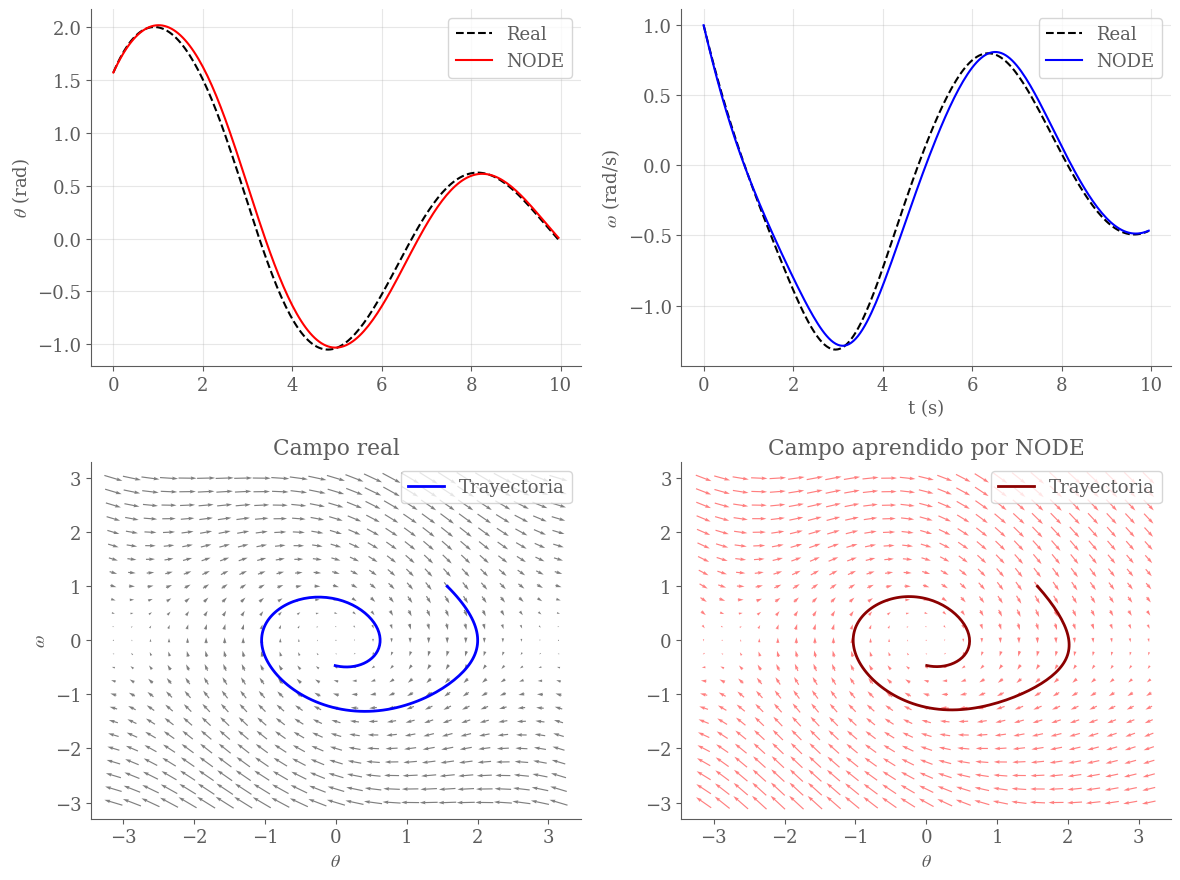

In [35]:
# === Validación: predicción vs física real ===

# CI fuera de la distribución de entrenamiento (omega0 > 2.0)
x0_test_np = np.array([np.pi/2, 1])

# Ground truth: integración del modelo físico real (sin ruido)
X_true = solve_ivp(pendulum, t_span, x0_test_np, t_eval=t).y.T

# Predicción del modelo NODE
model.eval()
with torch.no_grad():
    x0_test = torch.tensor(x0_test_np, dtype=torch.float32).to(device).unsqueeze(0)
    X_pred  = odeint(model, x0_test, t_tensor, method='rk4').squeeze(1).cpu().numpy()

mse_test = np.mean((X_true - X_pred)**2)
print(f"MSE en validación: {mse_test:.6f}")

# === Campo vectorial aprendido vs real (retrato de fase) ===

# Cuadrícula del espacio de fase
theta_vals = np.linspace(-np.pi, np.pi, 25)
omega_vals = np.linspace(-3.0, 3.0, 25)
Theta, Omega = np.meshgrid(theta_vals, omega_vals)

# Campo real
U_true = Omega
V_true = -b*Omega - (g/L)*np.sin(Theta)

# Campo aprendido por la red (sistema autónomo: t arbitrario)
grid_tensor = torch.tensor(np.vstack([Theta.ravel(), Omega.ravel()]).T,
                           dtype=torch.float32).to(device)
with torch.no_grad():
    d_pred = model(torch.tensor(0.0).to(device), grid_tensor).cpu().numpy()
U_pred = d_pred[:, 0].reshape(Theta.shape)
V_pred = d_pred[:, 1].reshape(Omega.shape)

# === Visualización 2x2 ===
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# Fila superior: comportamiento en el tiempo
ax[0,0].plot(t, X_true[:, 0], 'k--', label='Real')
ax[0,0].plot(t, X_pred[:, 0], 'r',   label='NODE')
ax[0,0].set_ylabel(r'$\theta$ (rad)'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

ax[0,1].plot(t, X_true[:, 1], 'k--', label='Real')
ax[0,1].plot(t, X_pred[:, 1], 'b',   label='NODE')
ax[0,1].set_ylabel(r'$\omega$ (rad/s)'); ax[0,1].set_xlabel('t (s)')
ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

# Fila inferior: retrato de fase (campo + trayectoria de validación)
ax[1,0].quiver(Theta, Omega, U_true, V_true, color='black', alpha=0.5, pivot='mid')
ax[1,0].plot(X_true[:, 0], X_true[:, 1], 'b', lw=2, label='Trayectoria')
ax[1,0].set_title('Campo real')
ax[1,0].set_xlabel(r'$\theta$'); ax[1,0].set_ylabel(r'$\omega$'); ax[1,0].legend()

ax[1,1].quiver(Theta, Omega, U_pred, V_pred, color='red', alpha=0.5, pivot='mid')
ax[1,1].plot(X_pred[:, 0], X_pred[:, 1], 'darkred', lw=2, label='Trayectoria')
ax[1,1].set_title('Campo aprendido por NODE')
ax[1,1].set_xlabel(r'$\theta$'); ax[1,1].legend()

plt.tight_layout(); plt.show()

### Ejercicio propuesto: Lotka-Volterra

Aplique el mismo procedimiento al sistema presa-depredador de Lotka-Volterra:

$$
\dot{x}_1 = \alpha x_1 - \beta x_1 x_2, \qquad \dot{x}_2 = \delta x_1 x_2 - \gamma x_2
$$

donde $x_1$ representa la población de presas y $x_2$ la de depredadores.

**Tareas:**

1. Genere múltiples trayectorias con distintas condiciones iniciales que cubran una región del plano $(x_1, x_2)$. Considere que las órbitas del sistema sin fricción son cerradas: una sola trayectoria no basta para cubrir el espacio de fase.
2. Entrene una NODE para aprender el campo vectorial $\mathbf{f}_{NN}(x_1, x_2; \theta)$.
3. Valide con una condición inicial nueva y compare el campo vectorial aprendido con el real.

**Preguntas para discusión:**

- ¿Cuántas trayectorias son suficientes para que la NODE reconstruya el retrato de fase?
- ¿Qué ocurre si se entrena con una única trayectoria? ¿La red generaliza a otras órbitas?
- ¿Cómo cambia el resultado si solo se observa una de las dos especies?